# Week 2

For this I will need 5 frames. 

- I will run inference on 5 frames.
- Testing hypothesis
- Document Gap 1




In [7]:
import cv2
import os
import glob

# Path to frame folder (NOT a video file!)
frames_folder = "/Users/niazahmad/Desktop/Research/explainable-video-anomaly-detection/SHANGHAI/SHANGHAI_Test/frames/01_0025"

# Get list of all frame files
frame_files = sorted(glob.glob(os.path.join(frames_folder, "*.jpg")))
total_frames = len(frame_files)
print(f"Total frames: {total_frames}")  # Should show ~600+

# Load a specific frame (e.g., frame 356)
def load_frame(frames_folder, frame_idx):
    """Load a single frame by index"""
    frame_path = os.path.join(frames_folder, f"{frame_idx:03d}.jpg")
    if os.path.exists(frame_path):
        frame = cv2.imread(frame_path)
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        return frame_rgb
    else:
        print(f"Frame {frame_idx} not found at {frame_path}")
        return None

# Load frame triplet (prev, curr, next)
def load_frame_triplet(frames_folder, frame_idx):
    """Load 3 consecutive frames for model input"""
    frames = {}
    for offset, name in [(-1, 'prev'), (0, 'curr'), (1, 'next')]:
        idx = frame_idx + offset
        frame_path = os.path.join(frames_folder, f"{idx:03d}.jpg")
        
        if os.path.exists(frame_path):
            frame = cv2.imread(frame_path)
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame_resized = cv2.resize(frame_rgb, (320, 160))
            frames[name] = frame_resized
        else:
            print(f"Warning: Frame {idx} not found")
            frames[name] = None
    
    return frames

# Test it
frame_356 = load_frame(frames_folder, 356)
print(f"Frame 356 shape: {frame_356.shape if frame_356 is not None else 'NOT FOUND'}")

Total frames: 601
Frame 356 shape: (480, 856, 3)


Total available frames: 601
First 20 frames: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
Is frame 356 available? True
Total available frames: 601


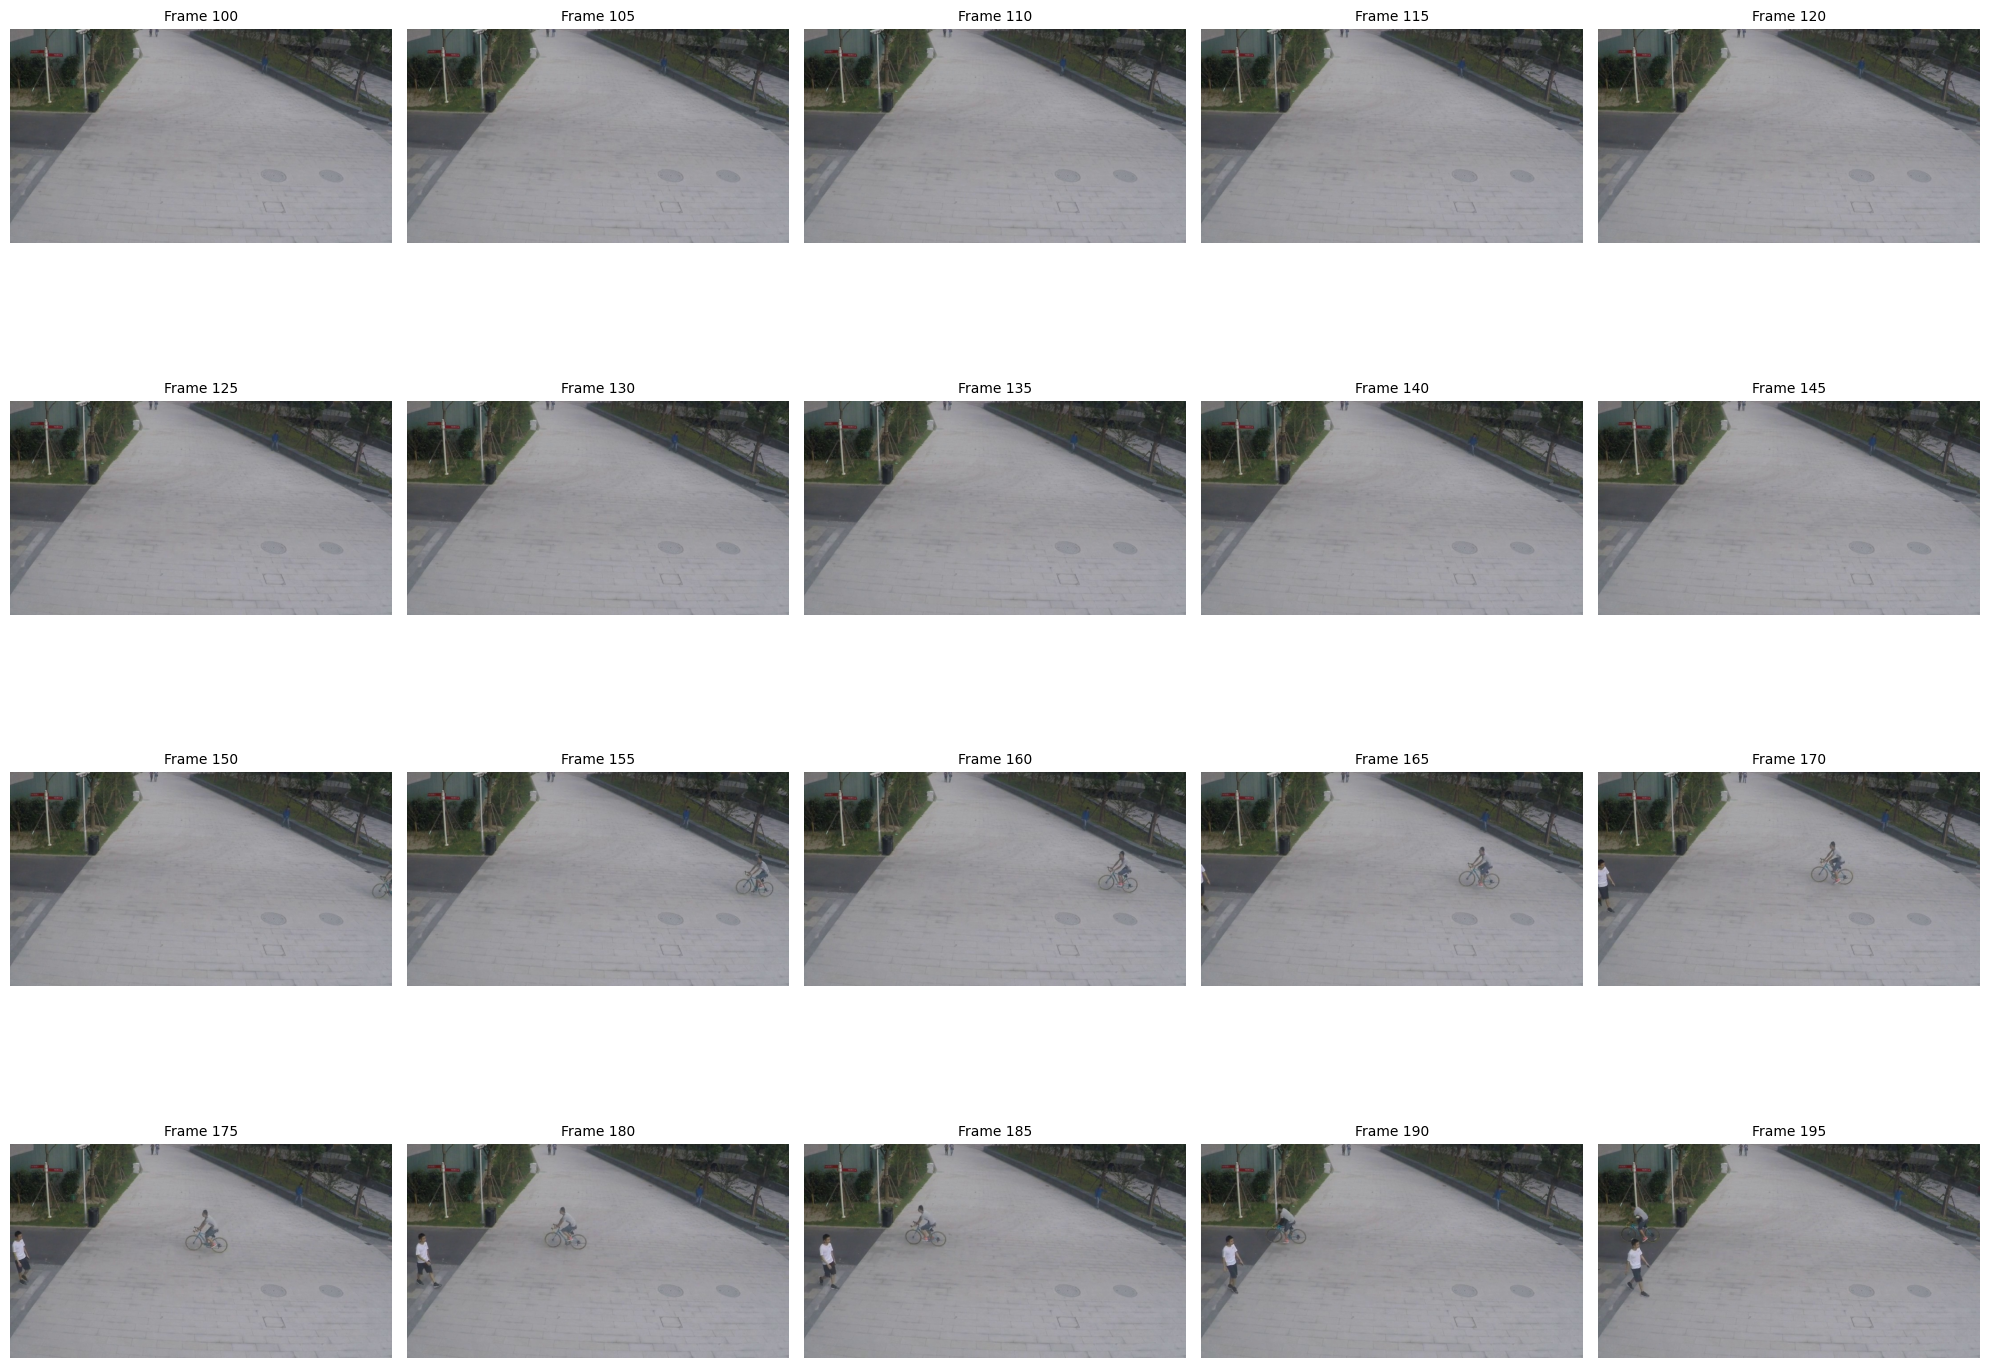

In [ ]:
# ============================================================
# WEEK 2 - CORRECTED FOR IMAGE FOLDERS (NOT VIDEO)
# ============================================================
import cv2
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
frames_folder = "/Users/niazahmad/Desktop/Research/explainable-video-anomaly-detection/SHANGHAI/SHANGHAI_Test/frames/01_0027"
# Get available frame indices
def get_available_frames(frames_folder):
    """Get list of available frame indices"""
    frame_files = glob.glob(os.path.join(frames_folder, "*.jpg"))
    indices = []
    for f in frame_files:
        filename = os.path.basename(f)
        idx = int(filename.replace('.jpg', ''))
        indices.append(idx)
    return sorted(indices)

available = get_available_frames(frames_folder)
print(f"Total available frames: {len(available)}")
print(f"First 20 frames: {available[:20]}")
print(f"Is frame 356 available? {356 in available}")


# Path to frames folder


# Get available frames
frame_files = sorted(glob.glob(os.path.join(frames_folder, "*.jpg")))
available_indices = [int(os.path.basename(f).replace('.jpg', '')) for f in frame_files]
print(f"Total available frames: {len(available_indices)}")

# Browse frames to select your 5 test frames
def browse_frames(frames_folder, start_idx=0, num_frames=20, step=20):
    """Display frames to help select test frames"""
    available = get_available_frames(frames_folder)
    
    # Get frames starting from start_idx
    frames_to_show = [f for f in available if f >= start_idx][:num_frames * step:step]
    
    cols = 5
    rows = (len(frames_to_show) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(20, 4*rows))
    axes = axes.flatten()
    
    for i, frame_idx in enumerate(frames_to_show):
        if i >= len(axes):
            break
        frame = load_frame(frames_folder, frame_idx)
        if frame is not None:
            axes[i].imshow(frame)
            axes[i].set_title(f"Frame {frame_idx}", fontsize=10)
        axes[i].axis('off')
    
    # Hide unused axes
    for j in range(i+1, len(axes)):
        axes[j].axis('off')
    
    plt.tight_layout()
    plt.show()

# Browse different sections
browse_frames(frames_folder, start_idx=100, num_frames=20, step=5)  # Around frame 356

In [ ]:
# 105, 145, 165, 190, from 25
# 125 from 27

frame_config = {
        'frame_1_video25_105': {
        'video': '01_0025',
        'index': 105,
        'human_description': "It completely normal picture and I should not see any anomaly and heatmap shouldnt be there",  # What do YOU see?
        'is_anomalous': False,  # Is it anomalous?
        'anomaly_type': "Normal",       # running? cycling? vehicle? normal walk?
        'expected_location': "None",  # Where is the anomaly? (top-left? center? bottom-right?)
        'expected_size': "None",      # How big? (~30px? ~60px? ~100px?)
        'hypothesis': "Model WILL detect because pretty easy to detect",
    },
    'frame_2_video25_145': {
        'video': '01_0025',
        'index': 145,
        'human_description': "It completely normal picture and I should not see any anomaly and heatmap shouldnt be there",  # What do YOU see?
        'is_anomalous': False,  # Is it anomalous?
        'anomaly_type': "Normal",       # running? cycling? vehicle? normal walk?
        'expected_location': "None",  # Where is the anomaly? (top-left? center? bottom-right?)
        'expected_size': "None",      # How big? (~30px? ~60px? ~100px?)
        'hypothesis': "Model WILL detect because pretty easy to detect",
    },
    'frame_3_video25_165': {
        'video': '01_0025',
        'index': 165,
        'human_description': "Has a clear anomaly and heatmap should be there, the cycle is at the center of the image",  # What do YOU see?
        'is_anomalous': True,  # Is it anomalous?
        'anomaly_type': "Cycling",       # running? cycling? vehicle? normal walk?
        'expected_location': "Center",  # Where is the anomaly? (top-left? center? bottom-right?)
        'expected_size': "None",      # How big? (~30px? ~60px? ~100px?)
        'hypothesis': "Model WILL detect because pretty easy to detect",
    },
    'frame_4_video25_190': {
        'video': '01_0025',
        'index': 190,
        'human_description': "It has a difficult to detect anomaly and heatmap should be there, the cycle is at the left end of the image, Also there is an a non amalous person walking. A heatmap should only show anomaly in the cycle  ",  # What do YOU see?
        'is_anomalous': True,  # Is it anomalous?
        'anomaly_type': "Cycling",       # running? cycling? vehicle? normal walk?
        'hypothesis': "Model WILL will detect but with a lower confidence score",
    },
    
}